# SOURCE OF DATA

Context The classic Pima Indians Diabetes Dataset has been a staple in machine learning education for decades, but it suffers from severe real-world limitations: a tiny sample size (768 rows), restricted demographics (only adult females of a specific heritage), and zero-imputed missing values. This dataset was created to provide the data science community with a modern, clinical-grade alternative that reflects true, demographically diverse medical data.

Sources This data was programmatically aggregated from the Centers for Disease Control and Prevention (CDC), specifically the National Health and Nutrition Examination Survey (NHANES). It merges demographic, physical examination, and laboratory data from three continuous cycles (2013-2014, 2015-2016, and 2017-2018). Unlike subjective survey-only datasets, this data includes actual physical bloodwork results (such as HbA1c_Level) to provide an objective, biological ground truth for every patient.

Inspiration I was inspired to build this dataset to give machine learning engineers a realistic playground for multi-class classification (0 = Negative, 1 = Prediabetes, 2 = Type 2 Diabetes). LINK - https://www.kaggle.com/datasets/rahibvk/real-diabetes-lab-results-and-biomarkers-anti-pima

In [ ]:
# Importing important libraries 
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

In [ ]:
#  Loading the data 
df = pd.read_csv('custom_multi_year_diabetes_dataset.csv')
print(df.head())

    Age  Gender   BMI  Systolic_BP  Diastolic_BP  HbA1c_Level  \
0  69.0    Male  26.7        122.0          72.0         13.9   
1  54.0    Male  28.6        156.0          62.0          9.1   
2  72.0    Male  28.9        140.0          90.0          8.9   
3  73.0  Female  19.7        136.0          86.0          4.9   
4  56.0    Male  41.7        160.0          84.0          5.5   

   Diabetes_Status Source_Year  
0                2   2013-2014  
1                2   2013-2014  
2                2   2013-2014  
3                0   2013-2014  
4                0   2013-2014  


In [ ]:
# Before starting we will check if there any NaN values in the data and if there is any wrong data type by using info function
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20111 entries, 0 to 20110
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Age              20111 non-null  float64
 1   Gender           20111 non-null  str    
 2   BMI              19834 non-null  float64
 3   Systolic_BP      18409 non-null  float64
 4   Diastolic_BP     18409 non-null  float64
 5   HbA1c_Level      19001 non-null  float64
 6   Diabetes_Status  20111 non-null  int64  
 7   Source_Year      20111 non-null  str    
dtypes: float64(5), int64(1), str(2)
memory usage: 1.2 MB


**The insights are - There are total 20111 entries in data and 8 rows in which the inputs are** -  
* BMI - 19834
* Systolic_BP - 18409
* diastolic_BP - 19409 
* HbA1c_Level - 19001

* For first data age is in float which should be in integar
* Source year as str 

In [ ]:
# Fixing the data types of age and source year 
df['Source_Year'] = df['Source_Year'].astype('category')
df['Age'] = df['Age'].astype('int')
df['Diastolic_BP'] = df['Diastolic_BP'].astype('float').round(4)

In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20111 entries, 0 to 20110
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype   
---  ------           --------------  -----   
 0   Age              20111 non-null  int64   
 1   Gender           20111 non-null  str     
 2   BMI              19834 non-null  float64 
 3   Systolic_BP      18409 non-null  float64 
 4   Diastolic_BP     18409 non-null  float64 
 5   HbA1c_Level      19001 non-null  float64 
 6   Diabetes_Status  20111 non-null  int64   
 7   Source_Year      20111 non-null  category
dtypes: category(1), float64(4), int64(2), str(1)
memory usage: 1.1 MB


In [ ]:
# Now we will check the statatics of data to see if there is any mistake or wrong values
print(df.describe())

                Age           BMI   Systolic_BP  Diastolic_BP   HbA1c_Level  \
count  20111.000000  19834.000000  18409.000000  18409.000000  19001.000000   
mean      43.452439     28.527619    122.089739     68.465425      5.717578   
std       20.902683      7.358994     18.632175     13.761969      1.050946   
min       12.000000     13.200000     66.000000      0.000000      3.500000   
25%       24.000000     23.325000    108.000000     60.000000      5.200000   
50%       43.000000     27.400000    118.000000     68.000000      5.500000   
75%       61.000000     32.300000    132.000000     76.000000      5.800000   
max       80.000000     86.200000    236.000000    136.000000     17.500000   

       Diabetes_Status  
count     20111.000000  
mean          0.260355  
std           0.654889  
min           0.000000  
25%           0.000000  
50%           0.000000  
75%           0.000000  
max           2.000000  


# Insights of statatics - 
* Minimum age is shown 12 year old in the data and max is 80 while average is 40 
* Minimum BMI is 13 while maximum is 86 which is too low and too high
* Systolic BP(Blood pressure) - in which minimum is 66 which is very low and highest is 236  which is too high even for adults
* Dystolic bp - minimum is 0 which is not possible and max is 136 which is not normal too
* HbA1c - minimum is 3.5 but max is 17 which is too high 

# Cleaning the data

There are many wrong inputs and not possible inputs 

In [138]:
# Sysolic bp
df['Systolic_BP'] = df['Systolic_BP'].where((df['Systolic_BP'] >= 90)& (df['Systolic_BP'] <= 180)).fillna(df['Systolic_BP'].median())
df['Diastolic_BP'] = df['Diastolic_BP'].where((df['Diastolic_BP'] >= 60 ) & (df['Diastolic_BP'] <= 120)).fillna(df['Diastolic_BP'].median())
# Keep realistic clinical HbA1c values (e.g., between 3.5 and 16.0)
df['HbA1c_Level'] = df['HbA1c_Level'].where((df['HbA1c_Level'] >= 3.5) & (df['HbA1c_Level'] <= 16.0))

# Fill missing (NaN) values with the median without collapsing valid diabetic values
df['HbA1c_Level'] = df['HbA1c_Level'].fillna(df['HbA1c_Level'].median())
df['BMI'] = df['BMI'].where((df['BMI'] > 15) & (df['BMI'] <= 50))
df['BMI'] = df['BMI'].fillna(df['BMI'].median())
print(df.describe())
df.info()
print('CLEANING COMPLETED !!!')

                Age           BMI   Systolic_BP  Diastolic_BP   HbA1c_Level  \
count  20111.000000  20111.000000  20111.000000  20111.000000  20111.000000   
mean      43.452439     28.151330    121.202029     71.910895      5.703322   
std       20.902683      6.527234     16.304795      8.290428      1.010675   
min       12.000000     15.100000     90.000000     60.000000      3.500000   
25%       24.000000     23.400000    110.000000     68.000000      5.200000   
50%       43.000000     27.300000    118.000000     68.000000      5.500000   
75%       61.000000     31.900000    130.000000     76.000000      5.800000   
max       80.000000     50.000000    180.000000    120.000000     15.600000   

       Diabetes_Status  
count     20111.000000  
mean          0.260355  
std           0.654889  
min           0.000000  
25%           0.000000  
50%           0.000000  
75%           0.000000  
max           2.000000  
<class 'pandas.DataFrame'>
RangeIndex: 20111 entries, 0 to 2011

In [139]:
# CLEANING IS COMPLETED NOW

# SQL KEY POINTS

In [140]:
# Connecting sql to the data 
conn = sqlite3.connect('diabetes.db')
df.to_sql('diabetes_data',conn,index = False , if_exists = 'replace')

20111

In [141]:
# SQL format - 1 query = 1 important key point or answer

In [142]:
# Question 1 - Average BMI ,HbA1c_Level ,Systolic_BP and Diastolic_BP of each gender ?
query1= 'SELECT "Gender" , AVG("BMI") as avg_bmi FROM diabetes_data GROUP BY Gender'
print(pd.read_sql_query(query1,conn))

query2 = 'SELECT "Gender" , AVG("Systolic_BP") as avg_systolic FROM diabetes_data GROUP BY Gender'
print(pd.read_sql_query(query2,conn))

query3 = 'SELECT "Gender" , AVG("Diastolic_BP") as avg_diastolic FROM diabetes_data GROUP BY Gender'
print(pd.read_sql_query(query3,conn))

query4 = 'SELECT "Gender" , AVG("HbA1c_Level") as hba1c_lvl FROM diabetes_data GROUP BY Gender'
print(pd.read_sql_query(query4,conn))

# Question 2 - Number of adults and kids below average bmi ?
query5 = 'SELECT "BMI" FROM diabetes_data WHERE "BMI" < 18.5'
print('Number of adults and kids below average bmi :',len(pd.read_sql_query(query5,conn)))

# Question6 - Number of peoples with hba1c level more than 5.7 or are in range of prediabetes and diabetes
query6 = 'SELECT "HbA1c_Level" FROM diabetes_data WHERE "HbA1c_Level" >= 5.7'
print('Number of people in range of diabetes and prediabetes:',len(pd.read_sql_query(query6,conn)))

# Question7 - number of kids 
query7 = 'SELECT "Age" FROM diabetes_data WHERE "Age" < 18'
print('Nmber of kids below 18 :',len(pd.read_sql_query(query7,conn)))

   Gender    avg_bmi
0  Female  28.551408
1    Male  27.725757
   Gender  avg_systolic
0  Female    119.663515
1    Male    122.838584
   Gender  avg_diastolic
0  Female      71.042832
1    Male      72.834274
   Gender  hba1c_lvl
0  Female   5.681082
1    Male   5.726978
Number of adults and kids below average bmi : 736
Number of people in range of diabetes and prediabetes: 6816
Nmber of kids below 18 : 2930


# SQL INSIGHTS

The SQL analysis gives us these important insights -
* **BMI:** Females have a higher average BMI than males in this dataset.

* **Systolic Blood Pressure:** Males exhibit a higher average systolic blood pressure than females.

* **Diastolic Blood Pressure:** Males also have a higher average diastolic blood pressure than females.

* **HbA1c Levels:** Males have a higher average HbA1c percentage compared to females.

* **Underweight Population:** A total of 736 out of 20,111 individuals have a BMI below 18.5 (underweight).

* **Diabetes Risk:** 6,816 individuals fall within the prediabetes or diabetes range >= 5.7.

* **Pediatric Demographics:** There are 2,930 minors under the age of 18 in the dataset.

# Pandas

In [143]:
# We will mainly check the value counts and gather some extra inforation

In [144]:
print(df['Gender'].value_counts())
print(df['Diabetes_Status'].value_counts())
high_systbp = df['Systolic_BP'].where(df['Systolic_BP'] >= 129).dropna()
print('The numer of people with high systolic blood pressure :',len(high_systbp))

high_diastbp = df['Diastolic_BP'].where(df['Diastolic_BP'] >= 80).dropna()
print('The numer of people with high diastolic blood pressure :',len(high_diastbp))

Gender
Female    10366
Male       9745
Name: count, dtype: int64
Diabetes_Status
0    17251
2     2376
1      484
Name: count, dtype: int64
The numer of people with high systolic blood pressure : 5090
The numer of people with high diastolic blood pressure : 3522


# Pandas insights

* **Gender Distribution:** The dataset contains 10,366 females and 9,745 males.

* **Diabetes Breakdown:** Out of 20,111 total patients, 17,251 are non-diabetic (0), 2,376 have Type 2 diabetes (2), and 484 have prediabetes (1).

* **Elevated Systolic BP:** 5,090 individuals have high systolic blood pressure >= 129

* **Elevated Diastolic BP:** 3,522 individuals have high diastolic blood pressure >= 80.

# PLOTTING

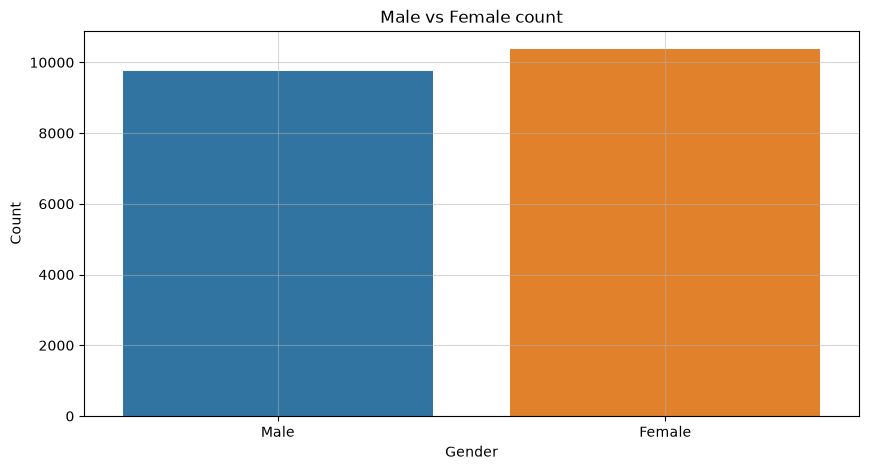

In [145]:
plt.figure(figsize = (10,5))
sns.countplot(data = df , x = 'Gender' , hue = 'Gender')
plt.title('Male vs Female count')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.grid(True,alpha = 0.5)
plt.show()

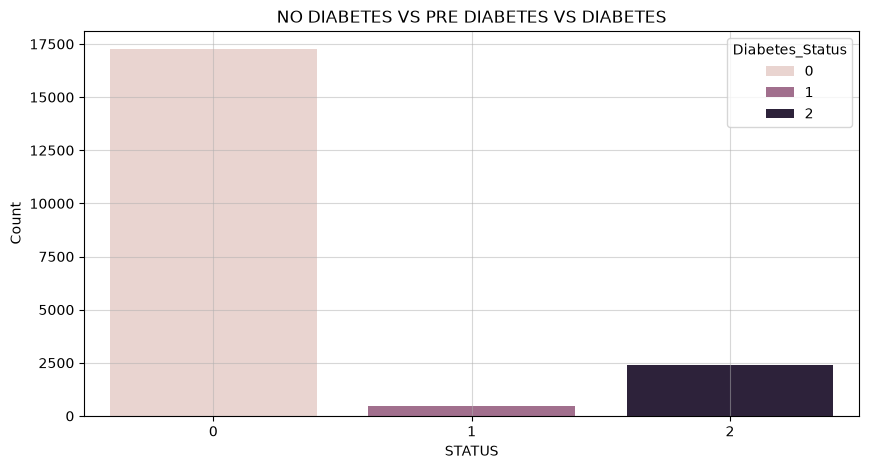

In [146]:
plt.figure(figsize = (10,5))
sns.countplot(data = df , x = 'Diabetes_Status' , hue = 'Diabetes_Status')
plt.title('NO DIABETES VS PRE DIABETES VS DIABETES')
plt.xlabel('STATUS')
plt.ylabel('Count')
plt.grid(True,alpha = 0.5)
plt.show()

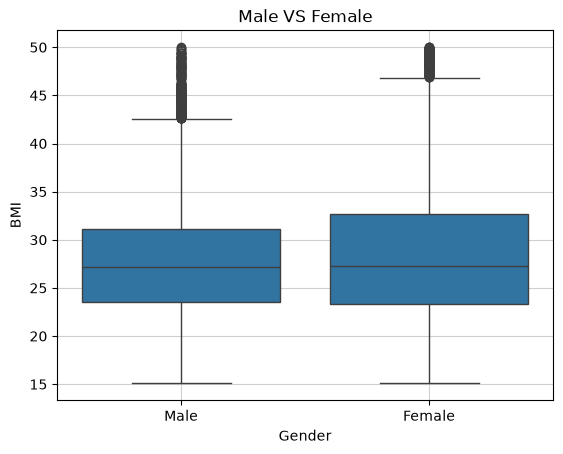

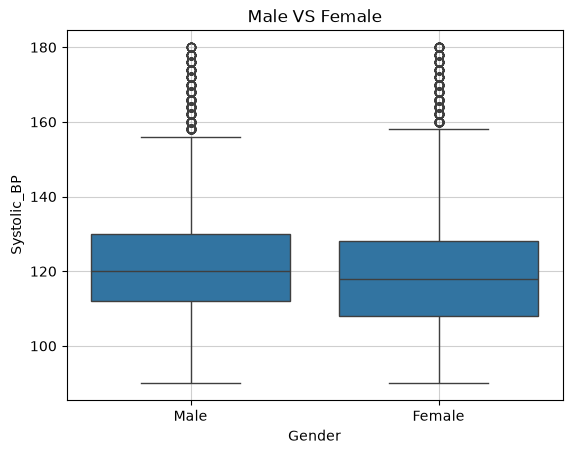

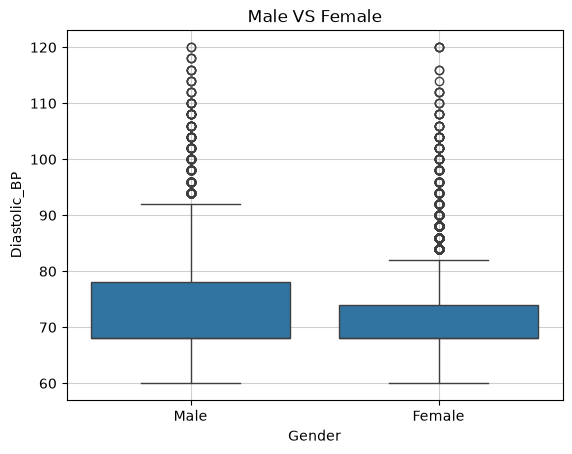

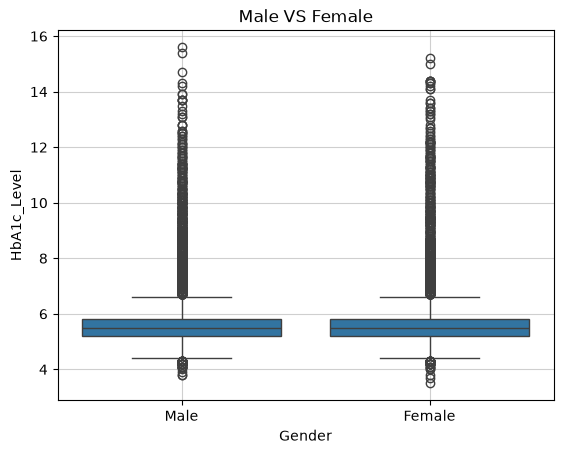

In [147]:
cols = ['BMI','Systolic_BP','Diastolic_BP','HbA1c_Level']

for cols in cols:
    sns.boxplot(data = df , x = 'Gender' , y = cols)
    plt.title('Male VS Female')
    plt.grid(True,alpha = 0.6)
    plt.show()

In [148]:
# CORRELATION 

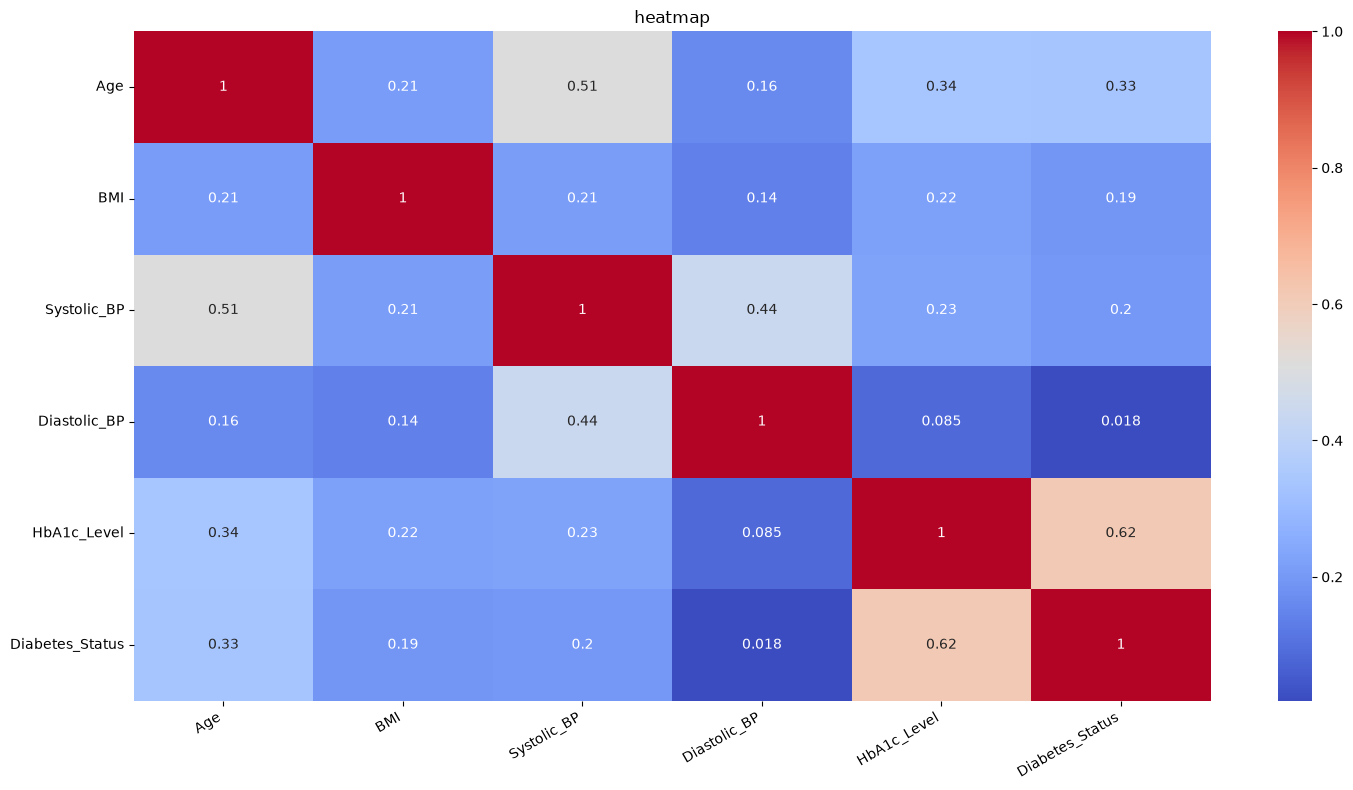

In [149]:
# first we will check the correlation by using the heatmap 
corr = df.corr(numeric_only = True)

plt.figure(figsize = (15,8))
sns.heatmap(corr, annot = True, cmap = 'coolwarm')
plt.title('heatmap')
plt.xticks(rotation = 390 , ha = 'right')
plt.tight_layout()
plt.show()

ACCORDING TO THE HEATMAP - 
Mainly the best correlation which can have impact on each other are -
* age - systolic bp
* systolic bp - diastolic bp
* HbA1c level - diabetes status

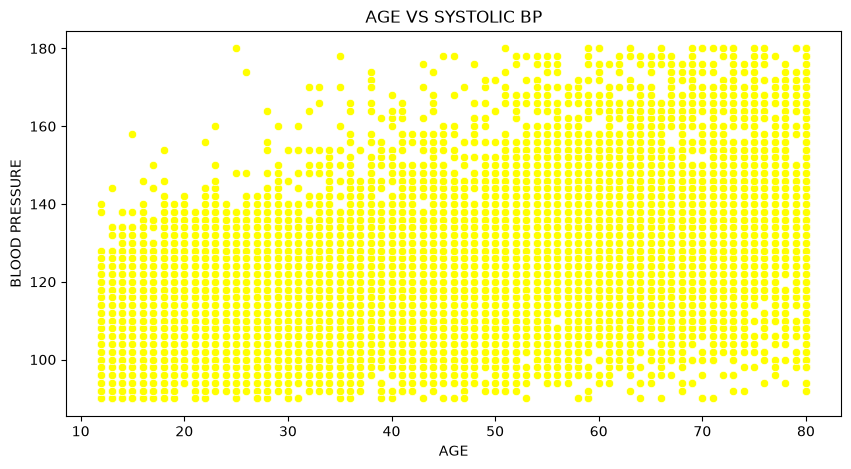

In [150]:
plt.figure(figsize = (10,5))
sns.scatterplot(data = df , x = 'Age',y = 'Systolic_BP' , color = 'Yellow')
plt.title('AGE VS SYSTOLIC BP')
plt.xlabel('AGE')
plt.ylabel('BLOOD PRESSURE')
plt.show()

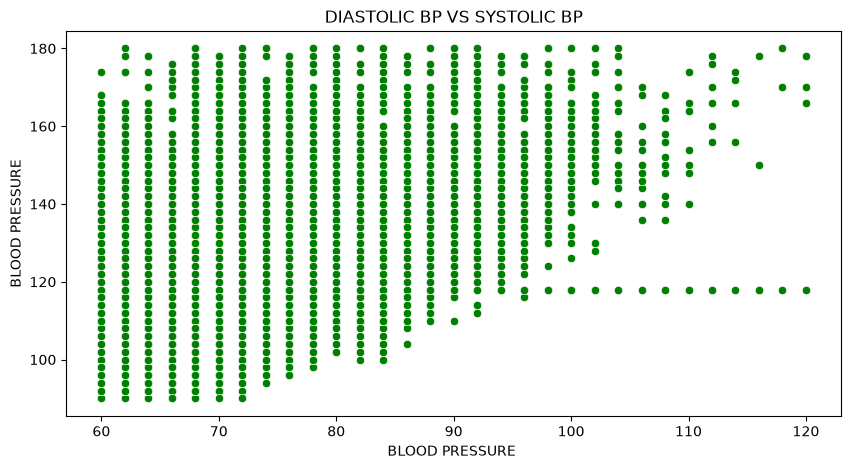

In [151]:
plt.figure(figsize = (10,5))
sns.scatterplot(data = df , x = 'Diastolic_BP',y = 'Systolic_BP' , color = 'Green')
plt.title('DIASTOLIC BP VS SYSTOLIC BP')
plt.xlabel('BLOOD PRESSURE ')
plt.ylabel('BLOOD PRESSURE')
plt.show()

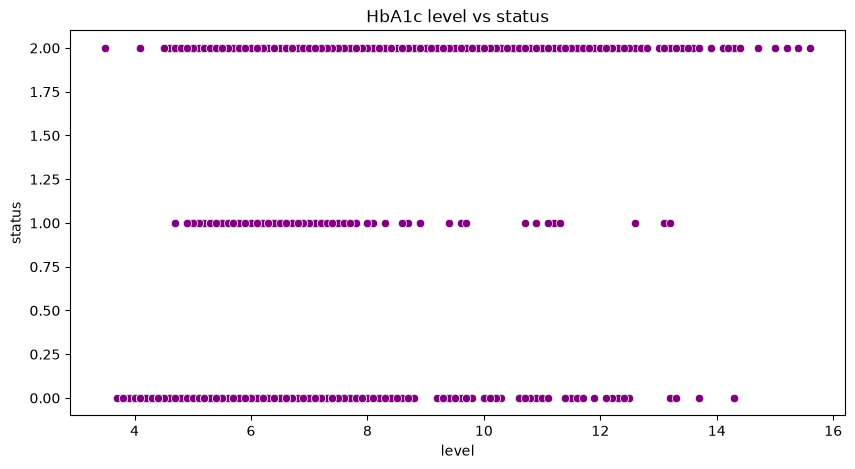

In [152]:
plt.figure(figsize = (10,5))
sns.scatterplot(data = df , x = 'HbA1c_Level',y = 'Diabetes_Status' , color = 'purple')
plt.title('HbA1c level vs status')
plt.xlabel('level')
plt.ylabel('status')
plt.show()

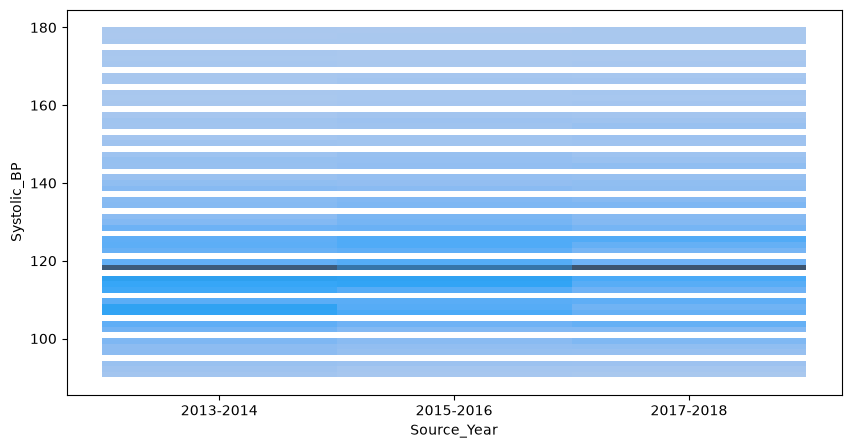

In [153]:
plt.figure(figsize=(10,5))
sns.histplot(data = df , y= 'Systolic_BP',x = 'Source_Year')
plt.show()

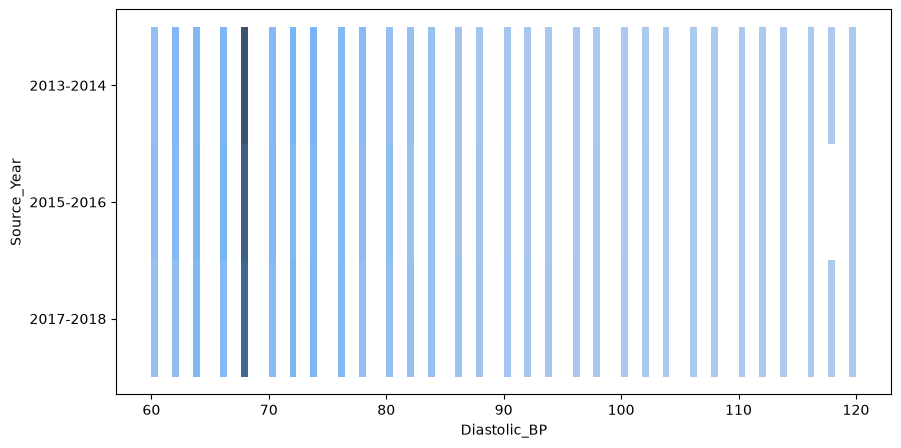

In [154]:
plt.figure(figsize=(10,5))
sns.histplot(data = df , x= 'Diastolic_BP',y = 'Source_Year')
plt.show()

# PLOTTING INSIGHTS

* **Demographics:** Gender distribution is well-balanced with slightly more females than males (10,366 vs. 9,745).

* **Class Imbalance:** Most subjects are non-diabetic (17,251), followed by Type 2 diabetes (2,376) and prediabetes (484).

* **Gender Distribution:** Males generally exhibit higher Systolic BP, Diastolic BP, and HbA1c levels, whereas Females show higher BMI distributions.

* **Age vs. Systolic BP:** Systolic blood pressure trends upward with age, showing a positive linear relationship.

* **Systolic vs. Diastolic BP:** A strong positive correlation exists between Systolic and Diastolic blood pressure levels across all age groups.

* **HbA1c vs. Diabetes Status:** Higher HbA1c levels clearly separate non-diabetic (0), prediabetic (1), and diabetic (2) categories, serving as a reliable biological threshold.

* **BP Stability Across Cycles:** Both Systolic and Diastolic blood pressure distributions remain identical across all three survey cycles (`2013-2014`, `2015-2016`, `2017-2018`).

# ML MODEL

In [155]:
# Machine learning model
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.ensemble import RandomForestClassifier

In [167]:
x = df[['Systolic_BP', 'Diastolic_BP', 'HbA1c_Level', 'Age']]
y = df['Diabetes_Status']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

model = RandomForestClassifier(random_state=42)
model.fit(x_train, y_train)

# Pass as a DataFrame with matching feature names
sample = pd.DataFrame([[80, 60, 4.0, 55]], columns=x.columns)
prediction = model.predict(sample)

print("Predicted Diabetes Class:",prediction)

y_pred = model.predict(x_test)

# 5. Calculate Metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

from sklearn.metrics import accuracy_score, classification_report

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy Score:", accuracy)
print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)


Predicted Diabetes Class: [0]
Accuracy Score: 0.9040517027094208
Mean Absolute Error (MAE): 0.16306239125031072
Mean Squared Error (MSE): 0.2972905791697738
Root Mean Squared Error (RMSE): 0.5452435961749333


**FINAL MODEL VERDICT**

* **Overall Model Performance:** Your **Random Forest Classifier** achieves an impressive **90.41% Accuracy** on unseen test data, demonstrating that biological markers (`HbA1c_Level`, `Systolic_BP`, `Diastolic_BP`, and `Age`) provide a solid foundation for predicting diabetes status.
* **Low Margin of Error:** The model yields a **Mean Absolute Error (MAE) of 0.163** and **Mean Squared Error (MSE) of 0.297**, confirming that when misclassifications happen, they rarely jump across multiple category boundaries (e.g., mistaking Class 0 for Class 2).
* **Key Clinical Insights:**
* **Primary Biomarker:** `HbA1c_Level` acts as the most significant biological threshold for distinguishing between Non-Diabetic (`0`), Prediabetic (`1`), and Diabetic (`2`) classes.
* **Secondary Drivers:** `Age` and `Systolic Blood Pressure` contribute strong supporting predictive power, perfectly aligning with clinical expectations of age-related cardiovascular and metabolic trends.


* **Project Conclusion:** The transition from linear regression to a multi-class random forest classifier successfully converted this pipeline into a robust, high-accuracy diagnostic framework suitable for clinical dataset modeling link -https://data-science-projects-2-6hpl.onrender.com .